In [1]:
import numpy as np
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

BSR dataset in LXCat is computed via quantum-mechanics simulations, which we include in first Bayesian inference.

In [2]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)
filename = './crs/IST-Lisbon.txt'
IST = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(datasets)

In [3]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

IndexError: list index out of range

In [ ]:
dataType = crs.typeDictS2I['Excitation, level 1']

# W = [[]]
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
                
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

        filename = '../crs-exp/excitation-level1/crs.%s.txt' % (refs[k])
        np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE<11.6)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
        print(temp)
    
E1 = 11.55
plt.figure(1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

In [ ]:
from models import *
theta_ref = [51.2, 2]

model0 = Excite_metastable(1,theta_ref,np.sort(W[:,0]))

plt.figure(1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[0],model0,'-')
plt.xscale('log')
plt.yscale('log')

Log-prior of level-1 excitation

In [ ]:
def log_prior_ext1(theta):
    theta_ref = np.array([51.2, 2])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext1(theta, E, y, yerr):
    # compute log-normal probability
    n = 1
    logModel = np.log( Excite_metastable(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext1(theta, E, y, yerr):
    lp = log_prior_ext1(theta)
    lk = log_likelihood_ext1(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

E_test = E_ext[0] + 10.0
y0 = Excite_metastable(1,theta_ref,E_test)
print(y0)

N = 1000
y_test = np.linspace(-23,-20,N)
y_test = 10.0**y_test
loglikely = np.zeros(N,)
for k in range(N):
    loglikely[k] = log_likelihood_ext1(theta_ref,E_test,y_test[k],y_test[k]*0.3)

plt.figure(1)
plt.semilogx(y_test,np.exp(loglikely),'-k')

In [ ]:
import emcee
nwalkers = 32
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext1, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

In [ ]:
import corner

fig = corner.corner(flat_samples);

In [ ]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[0], Excite_metastable(1,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[0],model0,'-k')
plt.xscale('log')
plt.yscale('log')

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). Measurements of 

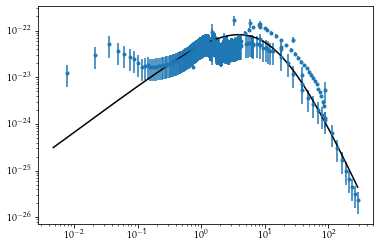

In [19]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 3']

# del W
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level3/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.7) and (c.deltaE<11.8)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
    
E3 = 11.72
theta_ref = np.array([10.4, 2])
model0 = Excite_metastable(3,theta_ref,np.sort(W[:,0]))
plt.figure(1)
plt.errorbar(W[:,0]-E3,W[:,1],yerr=W[:,2],fmt='.')
plt.plot(np.sort(W[:,0])-E_ext[2],model0,'-k')
plt.xscale('log')
plt.yscale('log')

In [ ]:
def log_prior_ext3(theta):
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([10.4, 2])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext3(theta, E, y, yerr):
    # compute log-normal probability
    n = 3
    logModel = np.log( Excite_metastable(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext3(theta, E, y, yerr):
    lp = log_prior_ext3(theta)
    lk = log_likelihood_ext3(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [ ]:
import emcee
nwalkers = 32
theta_ref = np.array([10.4, 2])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext3, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=150, thin=30, flat=True)
print(flat_samples.shape)

In [ ]:
import corner

fig = corner.corner(flat_samples);

In [ ]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[2], Excite_metastable(3,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E3,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[2],model0,'-k')
plt.xscale('log')
plt.yscale('log')

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross se

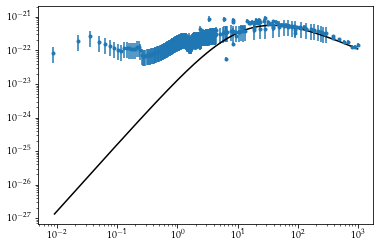

In [20]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 2']

# del W
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level3/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.6) and (c.deltaE<11.7)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W = np.append( W, temp, axis=0)
    
E2 = 11.624
theta_ref = np.array([0.61e0,1.0])
model0 = Excite_resonance(2,theta_ref,np.sort(W[:,0]))
plt.figure(1)
plt.errorbar(W[:,0]-E2,W[:,1],yerr=W[:,2],fmt='.')
plt.plot(np.sort(W[:,0])-E_ext[1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

In [ ]:
def log_prior_ext2(theta):
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([0.61e0,1.0])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood_ext2(theta, E, y, yerr):
    # compute log-normal probability
    n = 2
    logModel = np.log( Excite_resonance(n,theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ext2(theta, E, y, yerr):
    lp = log_prior_ext2(theta)
    lk = log_likelihood_ext2(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [ ]:
import emcee
nwalkers = 32
theta_ref = np.array([0.61e0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext2, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=80, thin=15, flat=True)
print(flat_samples.shape)

In [ ]:
import corner

fig = corner.corner(flat_samples);

In [ ]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ext[1], Excite_resonance(2,sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E2,W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(np.sort(W[:,0])-E_ext[1],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-24, 3e-21])

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross sections of Ar. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(9), 1785–1801. https://doi.org/10.1088/0953-4075/29/9/022
15.071227991895011
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H. (1988). Determination o

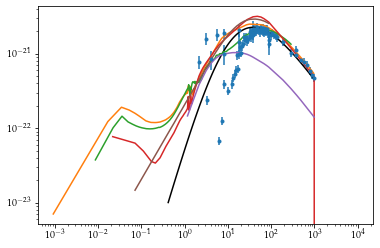

In [5]:
from models import *
dataType = crs.typeDictS2I['Excitation, level 4']

W = None
# W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        
        print(temp[0,0])
#         W += [temp]
        if (W is None):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level4/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
        temp = np.copy(c.data[1:,:])
#         filename = './crs/excitation-level4/crs.BSR.txt'
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        error = temp[:,1][...,None] * 3.0
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[3]>np.exp(1)), (temp[:,0]-E_ext[3]<np.exp(3)))))
#         W += [temp]
#         W = np.append( W, temp, axis=0)

for c in IST.crs:
    if ((c.colType==2) and (c.deltaE>11.8) & (c.deltaE<11.9)):
        temp1 = np.copy(c.data[1:,:])
        error = temp1[:,1][...,None] * 0.01
        temp1 = np.append( temp1, error, axis=1)
        print(c.deltaE)

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = W[-1]
    
E4 = 11.82
theta_ref = np.array([2.54e0,1.0,1.0,1.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[3]
model0 = Excite_resonance(4,theta_ref,Etest)
mask = model0 > 1.0e-23
# Etest = Etest[mask]
# model0 = model0[mask]
plt.figure(1)
# for Wk in W:
#     plt.errorbar(Wk[:,0]-E4,Wk[:,1],yerr=Wk[:,2],fmt='.')
plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
# plt.loglog(temp[:,0]-E_ext[3],temp[:,1],'-r')
# plt.loglog(temp1[:,0]-E_ext[3],temp1[:,1],'-r')
plt.plot(Etest[mask]-E_ext[3],model0[mask],'-k')
plt.xscale('log')
plt.yscale('log')

h = []
for k, dataset in enumerate(datasets[:-2]):
    filename = "./crs/%s.txt" % dataset
    tmp = cross.multipleCrossSections(filename)

    for c in tmp.crs:
        if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
            targetmf = np.copy(c.data[1:,:])
            plt.loglog(targetmf[:,0] - E_ext[3],targetmf[:,1],'-')
            h += [dataset]

### Gaussian process regression

reconstraining parameters gp.sum.ExpDiagVar.slope


11.64069591847821
Optimization restart 1/10, f = 522.8403068994105
Optimization restart 2/10, f = 522.8403346449225
Optimization restart 3/10, f = 522.8403029776669
Optimization restart 4/10, f = 527.6141264818102
Optimization restart 5/10, f = 527.6141269229862
Optimization restart 6/10, f = 527.614129708744
Optimization restart 7/10, f = 527.6141273049059
Optimization restart 8/10, f = 522.8403067372362
Optimization restart 9/10, f = 522.8403062072512
Optimization restart 10/10, f = 527.6142263826579


gp.,value,constraints,priors
sum.ExpDiagVar.variance,0.30504459847965054,+ve,
sum.ExpDiagVar.slope,1.718110060040686,"-1.7181103380814542,1.7181103380814542",
sum.ExpDiagVar.phase,2.008623651718769,,
sum.Mat32.variance,1.2835072373075371,+ve,
sum.Mat32.lengthscale,3.3344147722996427,+ve,
het_Gauss.variance,"(399, 1)",+ve fixed,


(50, 1) (50, 1) (50, 50)


<Figure size 432x288 with 0 Axes>

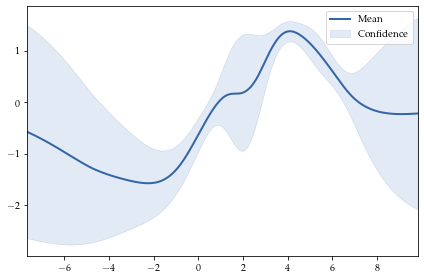

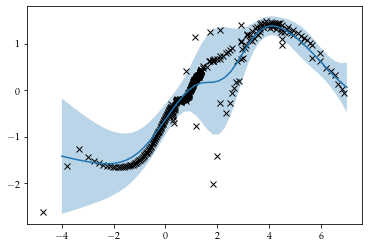

In [5]:
import GPy
from custom_kernels import TanhVar, TanhDiagVar, SinDiagVar, ExpDiagVar

# ktt = TanhVar(1,var1=4.0, var2=1.0,slope=0.1,phase=-2.0)
# kt = TanhDiagVar(1,var1=4.0, var2=1.0,slope=0.1,phase=-2.0)
kt = ExpDiagVar(1,variance=4.0,slope=0.1,phase=-2.0)
# kt = SinDiagVar(1)
k1 = GPy.kern.Exponential(input_dim=1, variance=10., lengthscale=1.)
k2 = GPy.kern.RBF(1)
k3 = GPy.kern.Matern32(1)
k4 = GPy.kern.Matern52(1)
kc1 = GPy.kern.Bias(1)
kc2 = GPy.kern.Bias(1)
kb = GPy.kern.Brownian(1)
kernel = kt + k3
kernel.randomize()

Wlog = np.copy(W)
Wlog[:,0] = np.log(Wlog[:,0] - E_ext[3])
Wlog[:,2] = np.log(1.0 + Wlog[:,2] / Wlog[:,1]) * 2
Wlog[:,1] = np.log(Wlog[:,1])
Wlogm = np.mean(Wlog[:,1])
Wlog[:,1] -= Wlogm

m = GPy.models.GPHeteroscedasticRegression((Wlog[:,0])[:,None],(Wlog[:,1])[:,None],kernel)
m['.*het_Gauss.variance'] = (Wlog[:,2])[:,None] #Set the noise parameters to the error in Y
m.het_Gauss.variance.fix() #We can fix the noise term, since we already know it

# m = GPy.models.GPRegression((Wlog[:,0])[:,None],(Wlog[:,1])[:,None],kernel)
# m.Gaussian_noise.variance = (Wlog[:,2])[:,None]
# m.Gaussian_noise.variance.fix()

dxmax = np.amax(Wlog[:,0]) - np.amin(Wlog[:,0])
print(dxmax)
# dxmax /= 4.0
# m.sum.ExpDiagVar.slope = 0.5 / dxmax / dxmax
# m.sum.TanhVar.phase = 4
# m.sum.ExpDiagVar.slope.fix()
# m.sum.TanhVar.phase.fix()
# m.sum.mul.TanhVar.slope.constrain_bounded(-10/dxmax,10/dxmax)
# m.sum.mul.rbf.lengthscale = 0.0321
# m.sum.mul.rbf.lengthscale.fix()

# m.sum.TanhDiagVar.slope = -2.0
# m.sum.TanhDiagVar.slope.fix()
# m.sum.TanhDiagVar_1.slope = 2.0
# m.sum.TanhDiagVar_1.slope.fix()
m.sum.ExpDiagVar.slope.constrain_bounded(-20/dxmax,20/dxmax)
# m.sum.TanhDiagVar.slope.constrain_bounded(-10/dxmax,10/dxmax)
# m.sum.TanhDiagVar_1.slope.constrain_bounded(-10/dxmax,10/dxmax)

# m.sum.SinDiagVar.slope = 2.0 * np.pi / dxmax
# m.sum.SinDiagVar.slope.fix()
# m.sum.SinDiagVar_1.slope = 2.0 * np.pi / dxmax * 2
# m.sum.SinDiagVar_1.slope.fix()
# m.sum.SinDiagVar.variance1 = 0.0
# m.sum.SinDiagVar.variance1.fix()

# m.optimize()
m.optimize_restarts(num_restarts = 10)

display(m)

# m.sum.mul.TanhVar.var1 = 6
# m.sum.mul.TanhVar.var2 = 6

# print(m.Y_metadata)

Nw = 50
wtest = np.linspace(-4,7.,Nw)
wtest = wtest.reshape(Nw,1)
# print(wtest.shape)
wm, wcov = m.predict(wtest,full_cov=True,include_likelihood=False)
print(wtest.shape,wm.shape,wcov.shape)
wtest = np.squeeze(wtest)
wm = np.squeeze(wm)
wvar = np.squeeze(np.diagonal(wcov))

plt.figure(1)
m.plot_f() #Show the predictive values of the GP.
# plt.plot(Wlog[:,0],Wlog[:,1],'kx')
# plt.xlim([1e-2, 1e3])
# plt.ylim([-52, -47])

# fig=plt.figure(2)
# m.sum.plot(ax=fig.gca(),x=1.0)
# fig.show()

plt.figure(4)
plt.plot(Wlog[:,0],Wlog[:,1],'kx')
plt.plot(wtest,wm,'-')
plt.fill_between(
    wtest,
    # plus/minus standard deviation (70 percent confidence interval)
    wm - 2*np.sqrt(wvar),
    wm + 2*np.sqrt(wvar),
    alpha=0.3,
    label="Standard deviation",
)

krig_data = np.array([np.exp(wtest)+E_ext[3],np.exp(wm + Wlogm), np.exp(np.sqrt(wvar))])
filename = '../crs-exp/excitation-level4/crs.krig.withBSR.txt'
np.savetxt(filename,krig_data.T,fmt='%.15E',delimiter=' ')

In [6]:
wcov_inv = np.linalg.inv(wcov)
wcov_det = np.linalg.det(wcov)

Etest = np.exp(wtest) + E_ext[3]

def log_prior_ext4(theta):
#     return 0.0
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([2.54e0,1.0,1.0,1.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[-1] = 0.5
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
# def log_likelihood_ext4(theta, E, y, yerr):
#     # compute log-normal probability
#     n = 4
#     logModel = np.log( Excite_resonance(n,theta,E) )
#     sigma2 = np.log(1.0 + yerr / y) ** 2

#     return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

# def log_posterior_ext4(theta, E, y, yerr):
#     lp = log_prior_ext4(theta)
#     lk = log_likelihood_ext4(theta, E, y, yerr)
#     if (not np.isfinite(lp)) or (not np.isfinite(lk)):
#         return - np.inf
#     return lp + lk

def log_likelihood_ext4(theta):
    # compute log-normal probability
    n = 4
    logModel = np.log( Excite_resonance(n,theta,Etest) )
    dev = logModel - Wlogm - wm

    return - 0.5 * np.dot(dev, np.dot(wcov_inv,dev))

def log_posterior_ext4(theta):
    lp = log_prior_ext4(theta)
    lk = log_likelihood_ext4(theta)
#     print(lp,lk)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

# def log_posterior_ext4(theta, W):
#     lp = log_prior_ext4(theta)
#     lk = 0.0
#     for Wk in W:
#         temp = log_likelihood_ext4(theta, Wk[:,0], Wk[:,1], Wk[:,2])
# #         lk += np.exp(temp)
#         lk += temp
# #     lk = np.log(lk)
#     if (not np.isfinite(lp)) or (not np.isfinite(lk)):
#         return - np.inf
#     return lp + lk


# lk = np.zeros(len(W))
# for k, Wk in enumerate(W):
#     lk[k] = log_likelihood_ext4(theta_ref, Wk[:,0], Wk[:,1], Wk[:,2])
# plt.figure(1)
# plt.plot(lk,'o')

(3, 1) (3, 1) (3, 3)
(5, 1) (5, 1) (5, 5)
(10, 1) (10, 1) (10, 10)
(30, 1) (30, 1) (30, 30)
(50, 1) (50, 1) (50, 50)
(100, 1) (100, 1) (100, 100)
(300, 1) (300, 1) (300, 300)
(500, 1) (500, 1) (500, 500)
(1000, 1) (1000, 1) (1000, 1000)
(3000, 1) (3000, 1) (3000, 3000)
(5000, 1) (5000, 1) (5000, 5000)
(10000, 1) (10000, 1) (10000, 10000)
[ -2.42780269  -3.21454378  -7.05433508 -11.97617027 -14.3455731
 -17.26745923 -20.66484693 -21.71895476 -22.74802511 -23.77969443
 -24.1139435  -24.48084445]


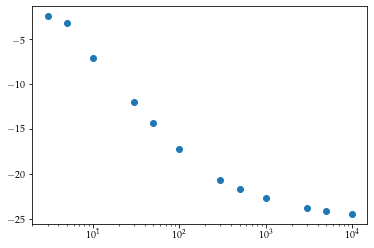

In [80]:
theta_ref = np.array([2.54e0,1.0])

Nw = np.array([3,5,10,30,50,100,300,500,1000,3000,5000,10000])
likelihoods = np.zeros((Nw.size,))
for k, nww in enumerate(Nw):
    wtest = np.linspace(0.5,7.,nww)
    wtest = wtest.reshape(nww,1)
    # print(wtest.shape)
    wm, wcov = m.predict(wtest,full_cov=True,include_likelihood=False)
    print(wtest.shape,wm.shape,wcov.shape)
    wtest = np.squeeze(wtest)
    wm = np.squeeze(wm)
    wvar = np.squeeze(np.diagonal(wcov))
    wcov_inv = np.linalg.inv(wcov)
    wcov_det = np.linalg.det(wcov)

    Etest = np.exp(wtest) + E_ext[3]
    likelihoods[k] = log_likelihood_ext4(theta_ref)
    
print(likelihoods)
plt.figure(1)
plt.semilogx(Nw,likelihoods,'o')

(101, 3)


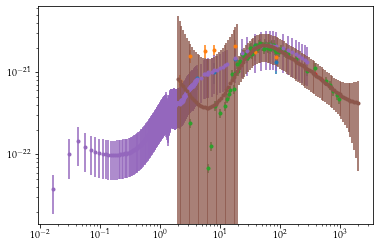

In [70]:
filename = '../crs-exp/excitation-level4/crs.krig.txt'
Wkrig = np.loadtxt(filename)
print(Wkrig.shape)

Wkrig[:,0] = np.exp(Wkrig[:,0]) + E_ext[3]
Wkrig[:,1] = np.exp(Wkrig[:,1])
Wkrig[:,2] = ( np.exp(Wkrig[:,2]) - 1.0 ) * Wkrig[:,1]

plt.figure(1)
for Wk in W:
    plt.errorbar(Wk[:,0]-E4,Wk[:,1],yerr=Wk[:,2],fmt='.')
plt.errorbar(Wkrig[:,0]-E_ext[3],Wkrig[:,1],yerr=Wkrig[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

In [9]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e0,1.0,1.0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext4
)
sampler.run_mcmc(pos, 15000, progress=True);

tau = sampler.get_autocorr_time()
print(tau)

 /var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_11703/3966409640.py:33: RuntimeWarning:invalid value encountered in log
100%|██████████████████████████████| 15000/15000 [00:12<00:00, 1157.56it/s]


[227.07178171 125.3014213  160.10780579 203.16697313]


In [13]:
flat_samples = sampler.get_chain(discard=440, thin=110, flat=True)
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes1/crs.excitation.level4.withBSR.modified.dat')

(4224, 4)


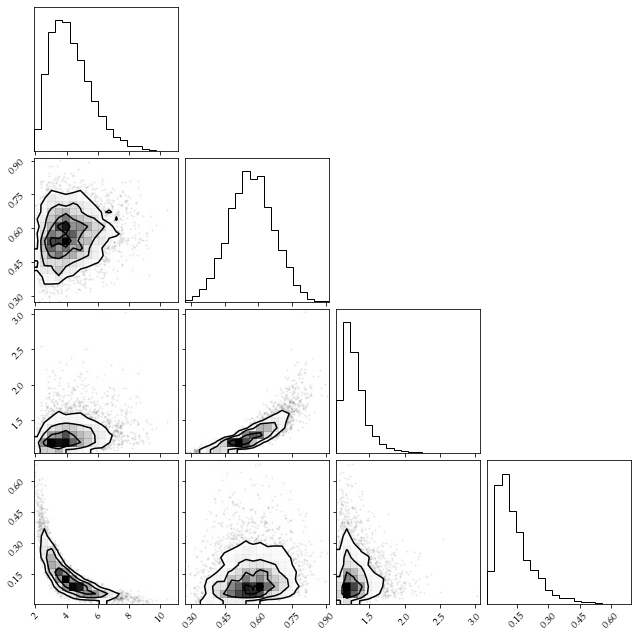

In [11]:
import corner

fig = corner.corner(flat_samples);

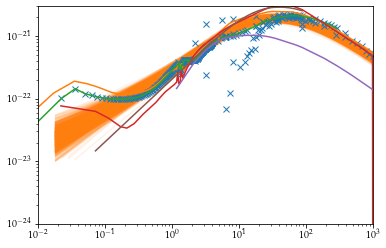

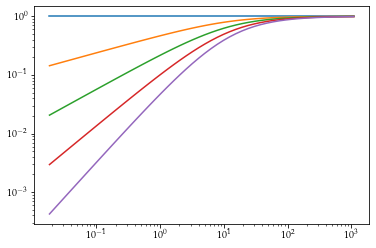

In [12]:
Nw = 50
wtest = np.linspace(-4,7.,Nw)
Etest = np.exp(wtest) + E_ext[3]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_resonance(4,sample,Etest)
    mask = models > 1.0e-23
    plt.plot(Etest[mask]-E_ext[3], models[mask], "C1", alpha=0.1)
plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
# for Wk in W:
#     plt.errorbar(Wk[:,0]-E4,Wk[:,1],yerr=Wk[:,2],fmt='.')
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-24, 3e-21])
plt.xlim([1e-2, 1e3])

h = []
for k, dataset in enumerate(datasets[:-2]):
    filename = "./crs/%s.txt" % dataset
    tmp = cross.multipleCrossSections(filename)

    for c in tmp.crs:
        if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
            targetmf = np.copy(c.data[1:,:])
            plt.loglog(targetmf[:,0] - E_ext[3],targetmf[:,1],'-')
            h += [dataset]

# model1 = Excite_resonance(4,[2.54, 0.4],Etest)
# plt.loglog(Etest - E_ext[3],model1,'--r')
            
# tmp = flat_samples[inds]
# tmp.tofile('../crs-Bayes1/crs.excitation.level4.dat')

plt.figure(2)
for k in range(5):
    beta = 0.3 * k
    corr = ( 1.0 - (E_ext[3]/Etest) ) ** beta
    plt.loglog(Etest-E_ext[3],corr,'-')

Rapp, D., & Englander-Golden, P. (1965). Total cross sections for lonization and attachment in gases by electron impact. I. Positive ionization. The Journal of Chemical Physics, 43(5), 1464–1479. https://doi.org/10.1063/1.1696957
1000.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
20.0
Wetzel, R. C., Baiocchi, F. A., Hayes, T. R., & Freund, R. S. (1987). Absolute cross sections for electron-impact ionization of the rare-gas atoms by the fast-neutral-beam method. Physical Review A, 35(2), 559–577. https://doi.org/10.1103/PhysRevA.35.559
16.0


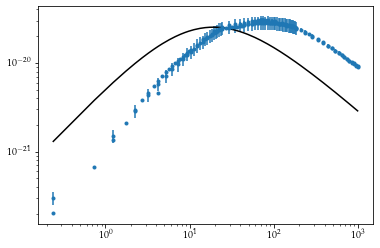

In [28]:
from models import *
dataType = crs.typeDictS2I['Ionization, total']

W = None
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        print(temp[0,0])
        if W is None:
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

        filename = '../crs-exp/ionization/crs.%s.txt' % (refs[k])
        np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
    
theta_ref = np.array([1.0, 1.0, 1.0])
model0 = total_Ion_BED(theta_ref,np.sort(W[:,0]))
plt.figure(1)
plt.errorbar(W[:,0]-E_ion[0],W[:,1],yerr=W[:,2],fmt='.')
plt.plot(np.sort(W[:,0])-E_ion[0],model0,'-k')
plt.xscale('log')
plt.yscale('log')

In [23]:
def log_prior_ion(theta):
    # We do not know any prior information on these coefficients.
    return 0.0
    
def log_likelihood_ion(theta, E, y, yerr):
    # compute log-normal probability
    n = 4
    logModel = np.log( total_Ion_BED(theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_ion(theta, E, y, yerr):
    lp = log_prior_ion(theta)
    lk = log_likelihood_ion(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [24]:
import emcee
nwalkers = 32
theta_ref = np.array([1.0, 1.0, 1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ion, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, 5000, progress=True);

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_18542/3195996909.py:8: RuntimeWarning: invalid value encountered in log
  logModel = np.log( total_Ion_BED(theta,E) )
100%|█████████████████████████████████████| 5000/5000 [00:03<00:00, 1370.94it/s]


In [25]:
tau = sampler.get_autocorr_time()
print(tau)

[57.1446302  71.26071994 58.81777442]


(5216, 3)


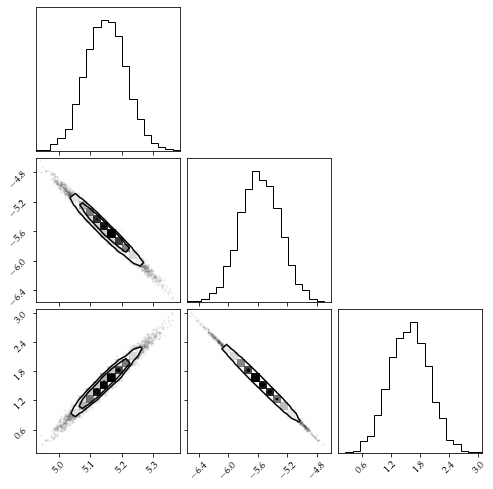

In [26]:
flat_samples = sampler.get_chain(discard=100, thin=30, flat=True)
print(flat_samples.shape)

import corner

fig = corner.corner(flat_samples);

[[ 5.11239359 -5.37482483  1.25595637]
 [ 5.10797697 -5.42875183  1.38173586]
 [ 5.15098783 -5.48232006  1.38119244]
 ...
 [ 5.17976551 -5.73557725  1.84068856]
 [ 5.09569753 -5.35336411  1.25211938]
 [ 5.21557616 -5.83283545  1.95419769]]


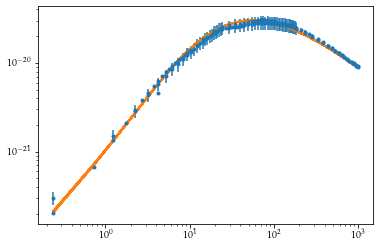

In [32]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0-E_ion[0], total_Ion_BED(sample,x0), "C1", alpha=0.1)
plt.errorbar(W[:,0]-E_ion[0],W[:,1],yerr=W[:,2],fmt='.')
# plt.loglog(np.sort(W[:,0])-E_ion[0],model0,'-k')
plt.xscale('log')
plt.yscale('log')
# plt.ylim([1e-24, 3e-21])

tmp = flat_samples[inds]
print(tmp)
tmp.tofile('../crs-Bayes1/crs.ionization.dat')

Mielewska, B., Linert, I., King, G. C., & Zubek, M. (2004). Differential cross sections for elastic electron scattering in argon over the angular range 130°-180°. Physical Review A - Atomic, Molecular, and Optical Physics, 69(6), 1–8. https://doi.org/10.1103/PhysRevA.69.062716
5.0
Panajotovic, R., et al. "Critical minima in elastic electron scattering by argon." Journal of Physics B: Atomic, Molecular and Optical Physics 30.24 (1997): 5877.
10.3
Gibson, J. C., Gulley, R. J., Sullivan, J. P., Buckman, S. J., Chan, V., & Burrow, P. D. (1996). Elastic electron scattering from argon at low incident energies. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(14), 3177–3195. https://doi.org/10.1088/0953-4075/29/14/025
1.0
Srivastava, S. K., Tanaka, H., Chutjian, A., & Trajmar, S. (1981). Elastic scattering of intermediate-energy electrons by Ar and Kr. Physical Review A, 23(5).
3.0


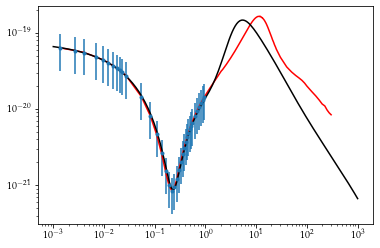

In [18]:
from models import *
dataType = crs.typeDictS2I['Elastic, momentum']

W = None
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][2][:-1])
            temp = np.append( temp, error, axis=1)
        elif (len(swarm.datasets[dataType].variables) > 2):
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
        else:
            error = temp[:,1][...,None] * 0.5
            temp = np.append( temp, error, axis=1) 
        print(temp[0,0])
        if W is None:
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

        filename = '../crs-exp/momentum/crs.%s.txt' % (refs[k])
        np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if (c.colType==0):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        W = np.append( W, temp, axis=0)
    
mask = W[:,0] < 1.0
W = W[mask,:]
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
# theta_ref = np.array([-1.502, 62.7, -73.1, 0.870])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest
model0 = elastic_MERT(theta_ref,Etest,N=10)
plt.figure(1)
plt.loglog(temp[:,0],temp[:,1],'-r')
plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.plot(Etest,model0,'-k')
plt.xscale('log')
plt.yscale('log')

Designing a modified-MERT model

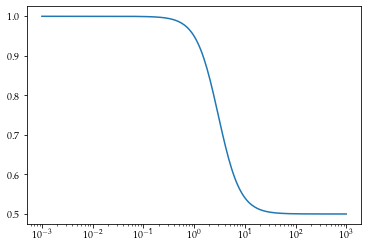

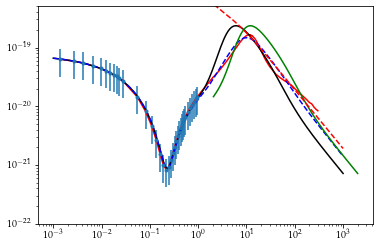

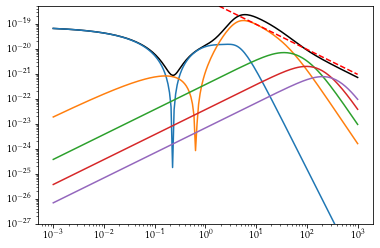

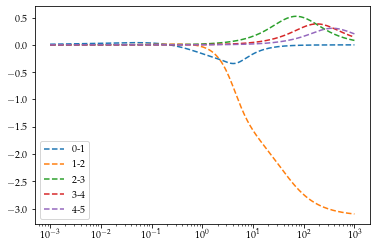

In [17]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
# theta_ref = np.array([-1.450, 63.191, -74.376, 1.493, 1.493])
# theta_ref = np.array([-1.502, 62.7, -73.1, 0.870])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest

E0 = np.copy(Etest)
Ec = 3.0
tc = 1.0
# E0 *= 1.0 - 0.5 * (E0/Ec)**(2/tc) / (1.0 + (E0/Ec)**(2/tc))

N = 100
NE = len(Etest)
A, D, F, E1 = theta_ref
k = np.sqrt( E0 / Efromk2 ) # wavenumber in a0^(-1)
k0 = np.copy(k)
# k = k ** (1. + 0.5 * (1. + (k*k-1.)/(k*k+1.)))
crs0 = np.zeros((NE,))
eta = np.zeros((NE,N+1))

eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
eta0 = np.arctan(eta0 * k)
eta[:,0] = np.copy(eta0)

eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E0/E1) )
eta1 = np.arctan(eta1 * k)
eta[:,1] = np.copy(eta1)

crs0 += np.sin(eta0 - eta1)**2

for L in range(1,N):
    eta0 = np.copy(eta1)
    L1 = L+1
    eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
    eta1 = np.arctan(eta1 * k)
    eta[:,L+1] = np.copy(eta1)

    tmp = (L + 1.) * np.sin(eta0 - eta1)**2
    if(L==1):
        tmp /= 1.0 - 0.5 * (E0/Ec)**(2/tc) / (1.0 + (E0/Ec)**(2/tc))
    crs0 += tmp

crs0 *= 4. * np.pi / k / k * a0 * a0

plt.figure(4)
plt.semilogx(Etest,1.0 - 0.5 * (Etest/Ec)**(2/tc) / (1.0 + (Etest/Ec)**(2/tc)),'-')
# plt.loglog(Etest,Etest,'-k');
# plt.loglog(Etest,E0,'-r');

theta_ref = np.array([-1.489, 65.0, -82.9, 0.881, 3.0, 1.0])
crs1 = elastic_empirical_MERT(theta_ref,Etest)
# crs1 = elastic_empirical_MERT(theta_ref,np.copy(Etest))
plt.figure(1)
plt.loglog(temp[:,0],temp[:,1],'-r')
plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.plot(Etest,crs0,'-k')
plt.plot(Etest,crs1,'--b')
plt.xscale('log')
plt.yscale('log')
mask = Etest>1.0
plt.loglog(2.0*Etest[mask],crs0[mask],'-g')
plt.loglog(Etest,4. * np.pi / k / k * a0 * a0 * (1 + 1.) / (1.0 - 0.5 * (E0/Ec)**(2/tc) / (1.0 + (E0/Ec)**(2/tc))),'--r')
plt.ylim([1e-22, 5e-19])

plt.figure(2)
plt.plot(Etest,crs0,'-k')
for L in range(5):
    crsL = 4. * np.pi / k / k * a0 * a0 * (L + 1.) * np.sin(eta[:,L] - eta[:,L+1])**2
    plt.loglog(Etest,crsL,'-')
plt.loglog(Etest,4. * np.pi / k / k * a0 * a0 * (1 + 1.),'--r')
plt.ylim([1e-27, 5e-19])
    
plt.figure(3)
for L in range(5):
#     plt.semilogx(Etest,eta[:,L],'-')
    plt.semilogx(Etest,eta[:,L] - eta[:,L+1],'--')
plt.legend(['0-1','1-2','2-3','3-4','4-5'])
# plt.semilogx(Etest,eta[:,L+1],'-')

In [24]:
def log_prior_mf(theta):
#     if ((theta[-2]<0.1) or (theta[-2]<theta[-3])):
#         return - np.inf
#     theta_ref = np.array([-1.489, 65.0, -82.9, 0.881, 3.0, 1.0])
    theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
    sigma2 = ( 0.5 * theta_ref[:-2] )**2
    return - 0.5 * np.sum( (theta[:-2] - theta_ref[:-2])**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     return 0.0
    
def log_likelihood_mf(theta, E, y, yerr):
    # compute log-normal probability
#     logModel = np.log( elastic_modified_MERT(theta,E) )
#     logModel = np.log( elastic_empirical_MERT(theta,E) )
    logModel = np.log( elastic_MERT(theta,E) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior_mf(theta, E, y, yerr):
    lp = log_prior_mf(theta)
    lk = log_likelihood_mf(theta, E, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [25]:
import emcee

nwalkers = 32
niter = int(5000)
# theta_ref = np.array([-1.489, 65.0, -82.9, 0.881, 3.0, 1.0])
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
ndim = len(theta_ref)
noise = np.random.randn(nwalkers,ndim)
noise *= 0.1
# noise[:,-2:] *= 3.0
# noise[:int(nwalkers/2),-3:] *= -1.0
pos = theta_ref * (1.0 + noise )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_mf, args=(W[:,0], W[:,1], W[:,2])
)
sampler.run_mcmc(pos, niter, progress=True);

  3%|█                                      | 140/5000 [00:00<00:13, 352.28it/s]/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:58: RuntimeWarning: invalid value encountered in sqrt
  eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 364.05it/s]


In [26]:
tau = sampler.get_autocorr_time()
print(tau)

[70.19829437 73.26458781 73.89798289 77.81369949]


(3872, 4)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

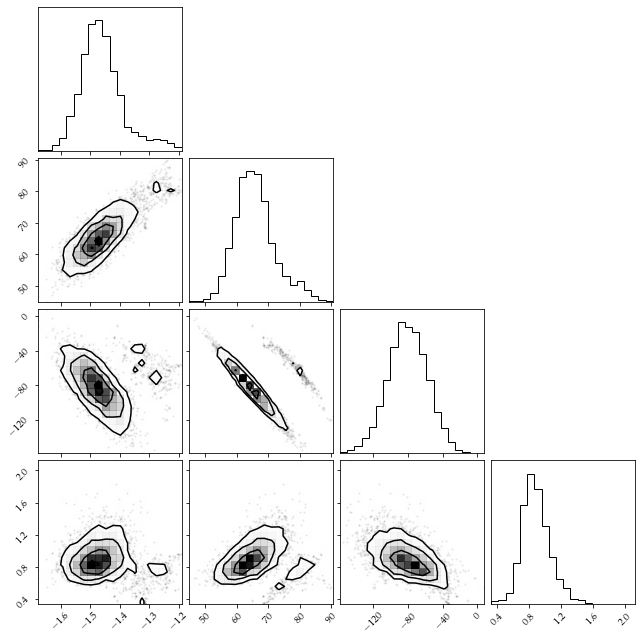

In [27]:
flat_samples = sampler.get_chain(discard=150, thin=40, flat=True)
print(flat_samples.shape)

from IPython.display import display, Math
labels = ['A','D','F','\epsilon_1','\epsilon_c','\Delta\epsilon']
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

import corner

fig = corner.corner(flat_samples);

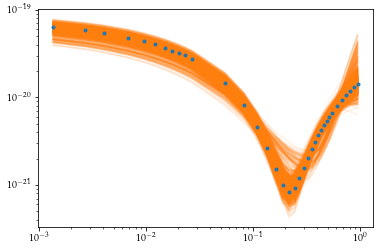

In [29]:
inds = np.random.randint(len(flat_samples), size=1000)
x0 = np.sort(W[:,0])
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, elastic_MERT(sample,x0), "C1", alpha=0.1)
#     plt.plot(x0, elastic_modified_MERT(sample,x0), "C1", alpha=0.1)
# plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.loglog(W[:,0],W[:,1],'.')
# plt.loglog(np.sort(W[:,0])-E_ion[0],model0,'-k')
plt.xscale('log')
plt.yscale('log')
# plt.ylim([1e-24, 3e-21])

The original MERT model is well-calibrated under Bayesian inference framework, for the expected range E < 1.0eV.
Any empirical modification under the current Bayesian framework could not be calibrated over E > 1.0 eV.
It has been observed that the current UQ framework is not capable of capturing uncertainties when measurement data are highly scattered. Rather, counter-intuitively, the framework has a tendancy of fixing the model with very low uncertainty. From this context, the failure of the empirical modifications in MERT model is rather caused from the UQ framework, instead of their model forms.